In [1]:
import h5py
from spectre.Visualization.ReadH5 import to_dataframe
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import glob
from spectre.Pipelines.ScalarSelfForce.Assemble import (
    assemble_scalar_self_force, sum_Fr4
)
from scipy.optimize import minimize
from spectre.PointwiseFunctions.AnalyticData.ScalarSelfForce import (
    CircularOrbit,
)
pd.set_option('display.float_format', '{:.6e}'.format)
# plt.style.use("/Users/nilsvu/Projects/Papers/2024/dg-self-force/scripts/paper.mplstyle")
plt.style.use("/Users/nilsvu/Projects/spectre/src/Visualization/Python/plots.mplstyle")

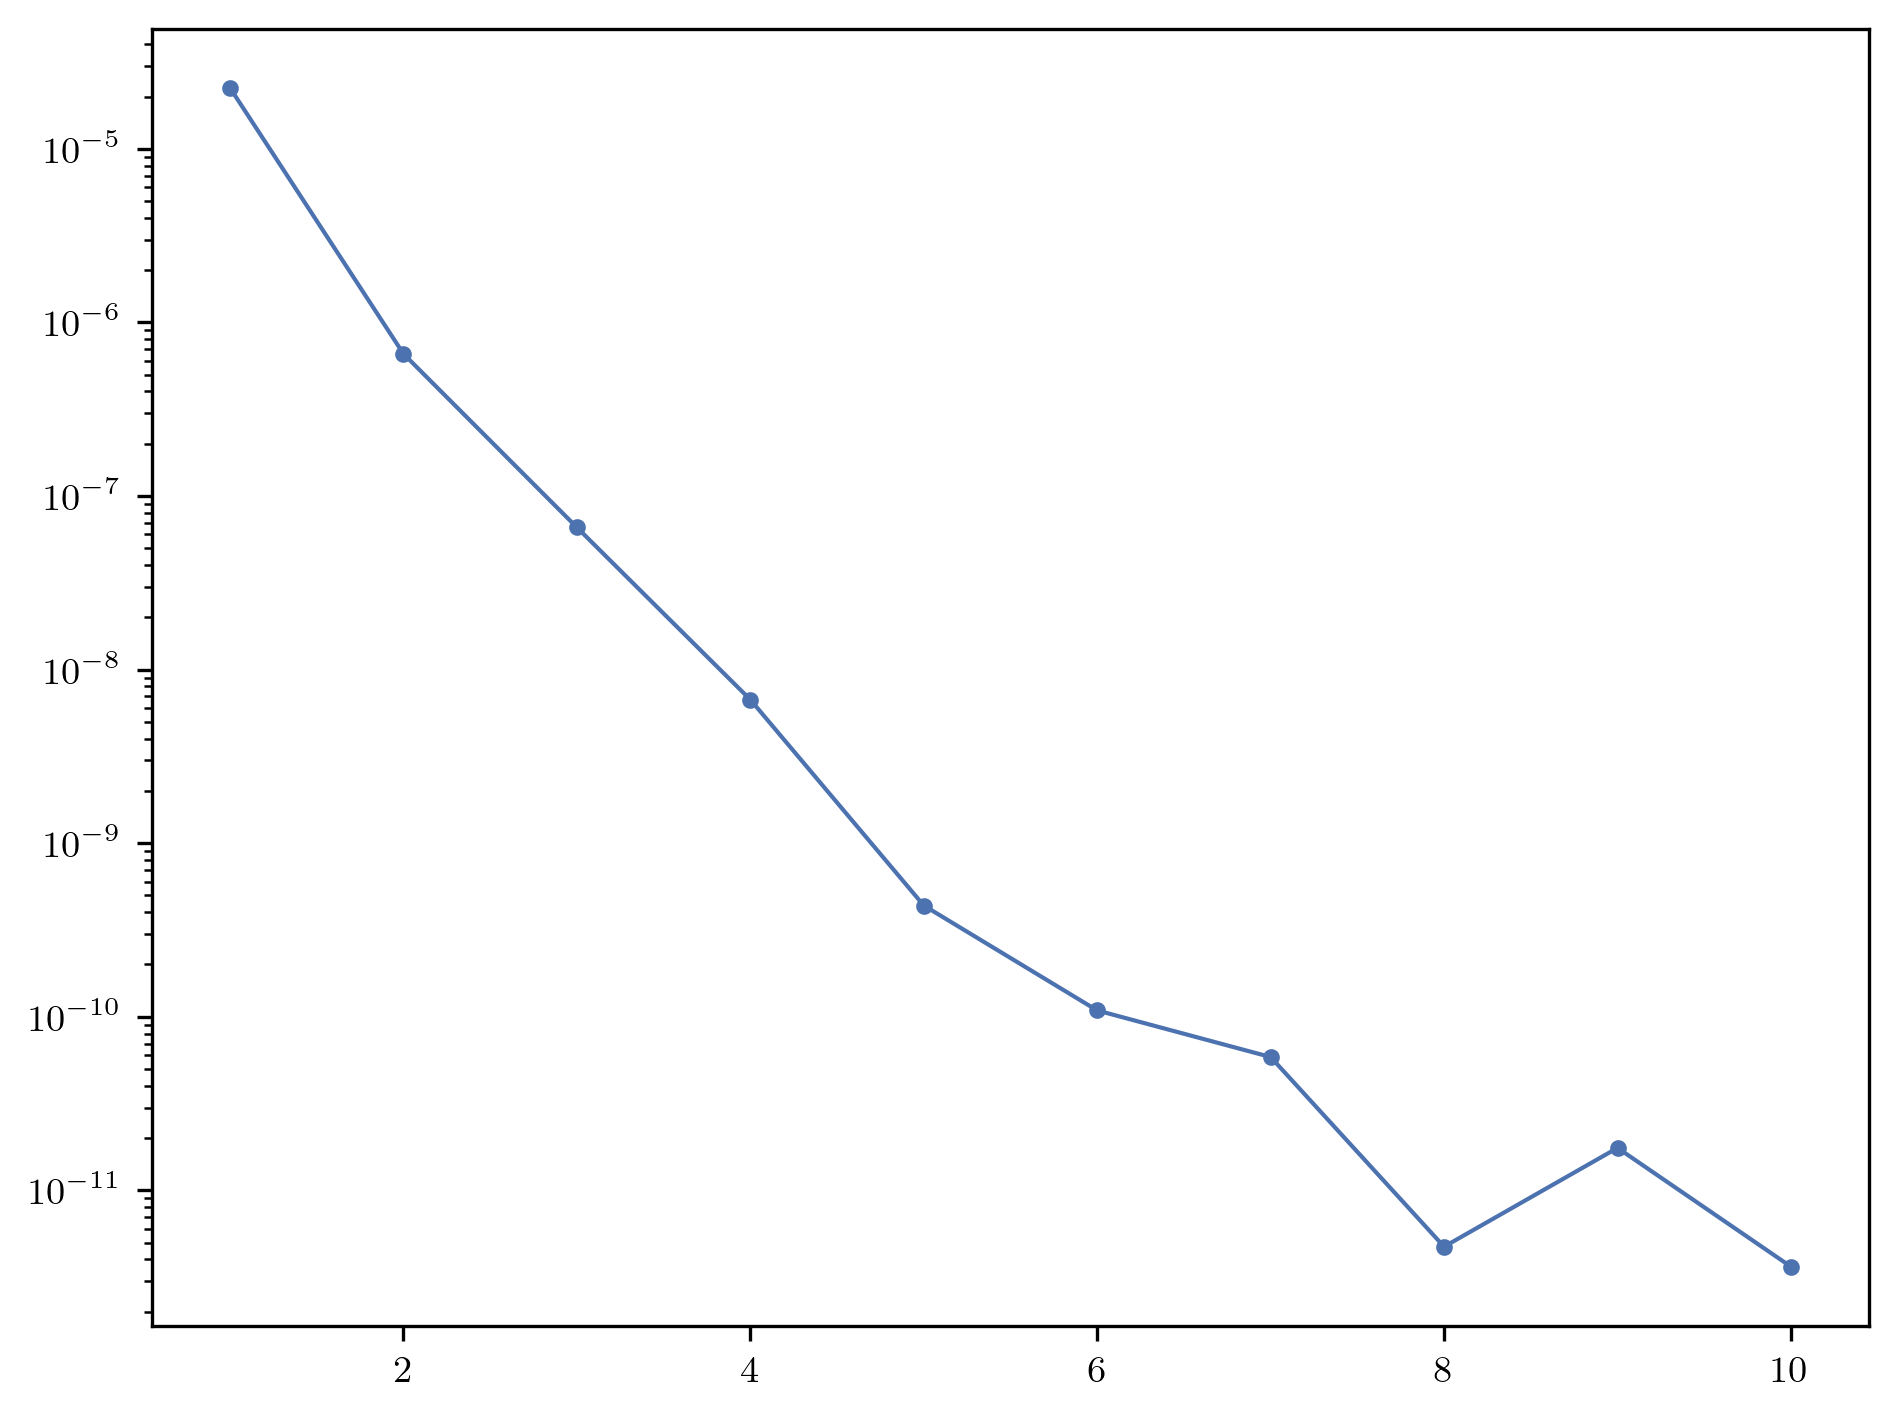

In [1342]:
import h5py
import matplotlib.pyplot as plt
from spectre.Visualization.ReadH5 import to_dataframe
# Load data
with h5py.File("/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf/ScalarSelfForceReductions.h5", "r") as f:
    df = to_dataframe(f["SelfForce.dat"]).set_index("IterationId")
# Average over neighboring elements at the puncture
self_force = df["Re(SelfForce_r)"].groupby("IterationId").mean()
# Plot difference to reference value
plt.semilogy(np.abs(self_force.iloc[1:] - -1.32916e-06), marker=".")

In [2]:
def r_isco(a):
    return minimize(
        lambda r: np.abs(
            1.0
            - 6.0 / r
            + 8.0 * a * np.sqrt(1.0 / r**3)
            - 3.0 * a**2 / r**2
        ),
        x0=6.0,
        bounds=[[2.0, 12.0]],
    ).x[0]

In [3]:
r_isco(a=0.9)

np.float64(2.3208830393069118)

In [5]:
CircularOrbit(
    black_hole_mass=1,
    black_hole_spin=0.9,
    orbital_radius=2.3208830393069118,
    m_mode_number=1,
    hyperboloidal_slicing_transitions=None,
    impose_equatorial_symmetry=False,
).puncture_position()[0]

-0.19710616673223758

In [6]:
import scipy.special

Tests for a=0.5, r0=10:

In [7]:
reference_sf = [[0.0,1.2652680881156312e-4,0.0],[2.4785455300555827e-5,-1.365170710329026e-4,-7.961776435907745e-4],[7.278128194979127e-6,-1.3291572725501146e-6,-2.3379368608573035e-4],[1.5902782332125908e-6,3.810535142852179e-6,-5.108415242000836e-5],[3.1470207660903283e-7,1.8752915639242087e-6,-1.0109104502997938e-5],[5.927827175925205e-8,7.894165575527185e-7,-1.9041826810563553e-6],[1.0842628182184181e-8,3.5022493341675776e-7,-3.4829532287142357e-7],[1.9451658024130903e-9,1.728350021488344e-7,-6.24841265241506e-8],[3.442183592031139e-10,9.477515040410666e-8,-1.1057249454879772e-8],[6.030046023090095e-11,5.659994853067909e-8,-1.937018212975947e-9],[1.048485424739129e-11,3.606853703505297e-8,-3.368026306901663e-10],[1.8154522536539399e-12,2.4152151102844248e-8,-5.831736717514891e-11],[3.163401444401203e-13,1.681516511865068e-8,-1.0161723789994383e-11],[5.856091806554566e-14,1.2081052288814544e-8,-1.8811392886090083e-12],[1.005629719844026e-14,8.912253993840976e-9,-3.230361883456454e-13],[2.5547975585393953e-15,6.720955189144775e-9,-8.206719123550592e-14],[1.3232706968479388e-15,5.165377999173894e-9,-4.250712897841582e-14],[1.1303280217524028e-15,4.036673828078404e-9,-3.6309274529377496e-14],[8.369124285619239e-14,3.1378689354465253e-9,-2.6883950977867265e-12],[1.2627894025883892e-15,2.5700095206125453e-9,-4.0564301874314637e-14],[6.9551077293623195e-15,2.0826933752730703e-9,-2.234173718309494e-13]]
reference_sf = np.array(reference_sf)

In [8]:
np.sum(reference_sf[:, 1]) + sum_Fr4(r0=10, a=0.5, m_max=len(reference_sf) - 1)

np.float64(-4.035309572998067e-06)

In [9]:
def get_data(file_path):
    with h5py.File(file_path, "r") as h5file:
        df = to_dataframe(h5file["SelfForce.dat"])
        num_points = to_dataframe(h5file["Norms.dat"])["NumberOfPoints"]
    return df, num_points

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'Absolute error $|F_r^m - F_{r,\\mathrm{ref}}^m|$')

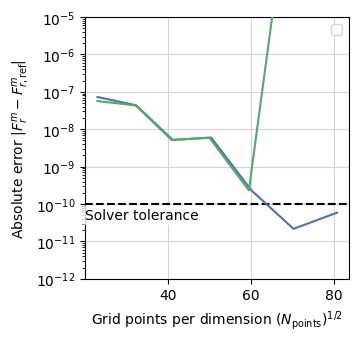

In [23]:
plt.figure(figsize=(3.4, 3.4))
# dirs = sorted(
#     glob.glob(
#         "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf39/m*/ScalarSelfForceReductions.h5"
#     ),
#     key=lambda x: int(x.split("/")[-2][1:]),
# )
dirs = sorted(
    glob.glob(
        "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf55/m*/ScalarSelfForceReductions.h5"
    ),
    key=lambda x: int(x.split("/")[-2][1:]),
)
dirs += sorted(
    glob.glob(
        "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf56/m*/ScalarSelfForceReductions.h5"
    ),
    key=lambda x: int(x.split("/")[-2][1:]),
)
ssf = pd.DataFrame(
    columns=["m", "SelfForce_r", "Reference", "Error"]
).set_index("m")
for i, filename in enumerate(
    dirs
    + [
        # "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf53/m2/ScalarSelfForceReductions.h5",
        # "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf51/m2/ScalarSelfForceReductions.h5",
        # "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf42/m1/ScalarSelfForceReductions.h5",
        # "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf32/m1/ScalarSelfForceReductions.h5",
    ]
):
    m = int(filename.split("/")[-2][1:])
    # P = int(filename.split("/")[-3][1:])
    df, num_points = get_data(filename)
    df_mean = df.groupby("IterationId").mean()
    if len(df_mean) <= 1:
        continue
    err = np.abs(
        df_mean["Re(SelfForce_r)"].iloc[1:-1]
        # - df_mean["Re(SelfForce_r)"].iloc[-1]
        - reference_sf[m, 1]
    )
    plt.plot(
        num_points[1:-1] ** (1 / 2),
        err,
        # marker=".",
        label=f"m={m}" if m == 0 or m == len(dirs) else None,
        # color=f"C{i}" if i > len(dirs) - 1 else 3 * [m / 20],
        zorder=100 - m,
        # ls={
        #     2: ":",
        #     3: "solid",
        #     4: "dashed",
        #     5: "dotted",
        #     6: "dashdot",
        # }[P]
        # alpha=1.0 if i >= len(dirs) else 0.5,
    )
    ssf.loc[m] = [
        df_mean["Re(SelfForce_r)"].iloc[-1],
        reference_sf[m, 1],
        err.iloc[-1],
    ]
plt.axhline(1e-10, color="k", linestyle="--", zorder=10)
plt.annotate(
    "Solver tolerance",
    (20, 1e-10),
    rotation=0,
    va="top",
    ha="left",
    xytext=(0, -3),
    textcoords="offset points",
    bbox=dict(
        boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8
    ),
)
plt.legend()
plt.yscale("log")
plt.grid()
plt.ylim(1e-12, 1e-5)
# plt.xlim(num_points.iloc[1]**0.5, num_points.iloc[-2]**0.5)
plt.xlabel("Grid points per dimension $(N_\mathrm{points})^{1/2}$")
plt.ylabel("Absolute error $|F_r^m - F_{r,\mathrm{ref}}^m|$")
# plt.savefig("ssf_convergence.pdf")

In [17]:
ssf

,SelfForce_r,Reference,Error
m,,,
2,-1.329164e-06,-1.329157e-06,1.483771e-11


In [1326]:
ssf[["SelfForce_r", "Reference"]].iloc[:-1].sum(axis=0) + sum_Fr4(r0=10, a=0.5, m_max=len(ssf) - 2)
# -4.03517e-6

SelfForce_r   -4.068833e-06
Reference     -4.068875e-06
dtype: float64

Text(0, 0.5, 'Contribution to $F_r$')

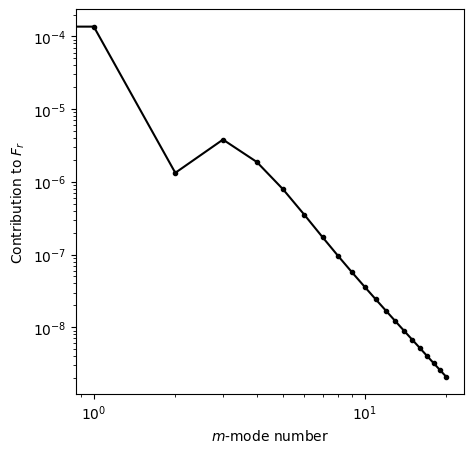

In [899]:
plt.figure(figsize=(5, 5))
plt.loglog(ssf.index, np.abs(ssf["SelfForce_r"]), marker=".", color="black")
plt.xlabel("$m$-mode number")
plt.ylabel("Contribution to $F_r$")

---

In [42]:
with h5py.File(
    "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf2_m1/ScalarSelfForceReductions.h5",
    "r",
) as h5file:
    df = to_dataframe(h5file["SelfForce.dat"])
    num_points = to_dataframe(h5file["Norms.dat"])["NumberOfPoints"]

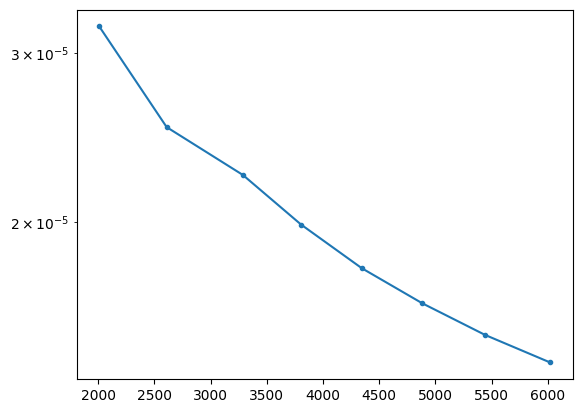

In [113]:
df_std = df.groupby("IterationId").std()
plt.plot(
    num_points[1:-1],
    df_std["Re(SelfForce_r)"].iloc[1:-1],
    marker="."
)
plt.yscale("log")

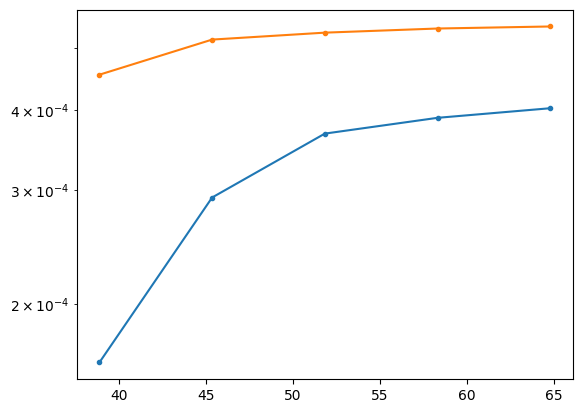

In [124]:
ref = (
    get_data(
        "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf18_m1/ScalarSelfForceReductions.h5"
    )[0]
    .groupby("IterationId")
    .mean()
    .iloc[-1]
)
for i, filename in enumerate(
    [
        # "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf_m1/ScalarSelfForceReductions.h5",
        # "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf2_m1/ScalarSelfForceReductions.h5",
        # "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf3_m1/ScalarSelfForceReductions.h5",
        # "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf4_m1/ScalarSelfForceReductions.h5",
        # "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf5_m1/ScalarSelfForceReductions.h5",
        # "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf6_m1/ScalarSelfForceReductions.h5",
        "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf17_m1/ScalarSelfForceReductions.h5",
        "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf19_m1/ScalarSelfForceReductions.h5",
    ]
):
    df, num_points = get_data(filename)
    df_mean = df.groupby("IterationId").mean()
    plt.plot(
        num_points[1:] ** (1 / 2),
        np.abs(
            df_mean["Re(SelfForce_r)"].iloc[1:]
            # - df_mean["Re(SelfForce_r)"].iloc[-1]
            - ref["Re(SelfForce_r)"]
        ),
        marker=".",
    )
plt.yscale("log")

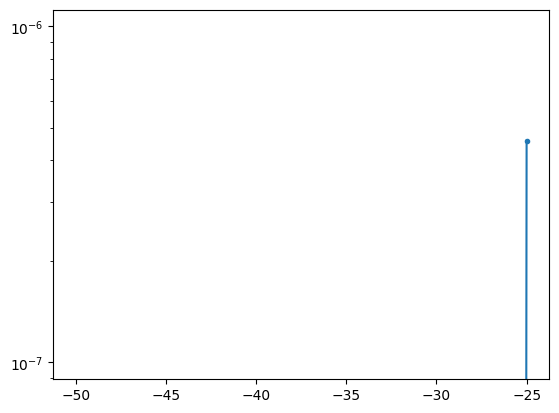

In [122]:
dir = "/Users/nilsvu/Projects/spectre/build-Default-Release"
data = []
# for R in [100, 200, 300, 400]:
for R in [-25, -50]:
    df, num_points = get_data(
        f"{dir}/test_ssf14_m1/Rin{R}/ScalarSelfForceReductions.h5"
    )
    df_mean = df.groupby("IterationId").mean()
    data.append((R, df_mean.iloc[-1]["Re(SelfForce_r)"]))
data = np.array(data)
plt.plot(
    data[:, 0],
    np.abs(data[:, 1] - data[-1, 1]),
    marker=".",
)
plt.yscale("log")

   SelfForce_r
m             
0     0.006934
1    -0.006138
2    -0.000961
3    -0.000129
4     0.000039
5     0.000056
6     0.000042
7     0.000027
8     0.000017
9     0.000011
10    0.000007
Before regularization: -9.49576829051947e-05
-8.123019918137199e-05


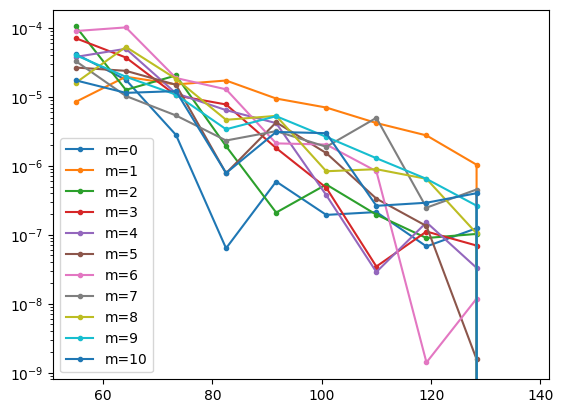

In [57]:
dirs = sorted(
    glob.glob(
        "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf26/m*/ScalarSelfForceReductions.h5"
    ),
    key=lambda x: int(x.split("/")[-2][1:]),
)
for filename in dirs:
    m = int(filename.split("/")[-2][1:])
    df, num_points = get_data(filename)
    df_mean = df.groupby("IterationId").mean()
    plt.plot(
        num_points[1:] ** (1 / 2),
        np.abs(
            df_mean["Re(SelfForce_r)"].iloc[1:]
            # - df_mean["Re(SelfForce_r)"].iloc[-1]
            - df_mean["Re(SelfForce_r)"].iloc[-1]
        ),
        marker=".",
        label=f"m={m}",
    )
plt.legend()
plt.yscale("log")
assemble_scalar_self_force(dirs, r0=4.2330025279799335, a=0.5)
# for a=0.5, r0=isco:
# F_r = −6.922147e−5

   SelfForce_r
m             
0     0.006934
1    -0.006138
2    -0.000961
3    -0.000129
4     0.000039
5     0.000055
6     0.000041
7     0.000025
8     0.000012
9      0.00001
10    0.000018
Before regularization: -9.461212245058013e-05
-8.088463872675742e-05


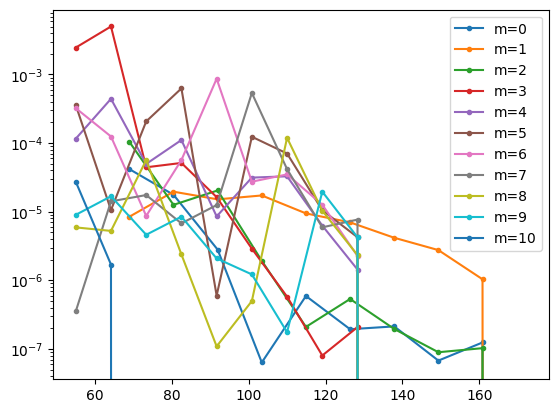

In [59]:
dirs = sorted(
    glob.glob(
        "/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf27/m*/ScalarSelfForceReductions.h5"
    ),
    key=lambda x: int(x.split("/")[-2][1:]),
)
for filename in dirs:
    m = int(filename.split("/")[-2][1:])
    df, num_points = get_data(filename)
    df_mean = df.groupby("IterationId").mean()
    plt.plot(
        num_points[1:] ** (1 / 2),
        np.abs(
            df_mean["Re(SelfForce_r)"].iloc[1:]
            # - df_mean["Re(SelfForce_r)"].iloc[-1]
            - df_mean["Re(SelfForce_r)"].iloc[-1]
        ),
        marker=".",
        label=f"m={m}",
    )
plt.legend()
plt.yscale("log")
assemble_scalar_self_force(dirs, r0=4.2330025279799335, a=0.5)
# for a=0.5, r0=isco:
# F_r = −6.922147e−5

In [ ]:
# a=0.9, r0=isco, m=1
expected_dpsi_drstar = -0.0242004 - 0.00723707j
expected_F_r = -0.0700412
# a=0.5, r0=6, m=1
dpsi_dr = -0.00320376 + 0.00162401j
F_r = -0.00120398
# m=0
dpsi_dr = 0.00355094
F_r = 0.00123093

In [25]:
df = get_data(*glob.glob("/Users/nilsvu/Projects/spectre/build-Default-Release/test_ssf24_*/m1/ScalarSelfForceReductions.h5"))[0]
df_mean = df.groupby("IterationId")["Re(SelfForce_r)"].mean()
df_mean

IterationId
0.0    0.000000
1.0   -0.001148
2.0   -0.001179
3.0   -0.001191
4.0   -0.001196
5.0   -0.001199
6.0   -0.001201
7.0   -0.001202
8.0   -0.001203
Name: Re(SelfForce_r), dtype: float64